In [1]:
import os
os.environ["https_proxy"] = "http://127.0.0.1:37890"
os.environ["http_proxy"] = "http://127.0.0.1:37890"
os.environ["all_proxy"] = "socks5://127.0.0.1:37890"
import matplotlib.pyplot as plt

In [2]:
from diffusers import DiTPipeline, DPMSolverMultistepScheduler,DiTPipeline
import torch
import numpy as np
import utils


2025-07-29 14:14:59.314926: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-29 14:14:59.328824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753798499.346267 1799987 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753798499.351228 1799987 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753798499.363981 1799987 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
import torch
from diffusers import StableDiffusion3Pipeline,DPMSolverMultistepScheduler
device = "cuda"
pipeline = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-large", torch_dtype=torch.bfloat16,local_files_only=True)
pipeline = pipeline.to(device)



Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [1]:
from PIL import Image
from typing import Any, Callable, Dict, List, Optional, Union, Tuple
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusion3Pipeline,StableDiffusion3Img2ImgPipeline
from diffusers.pipelines.stable_diffusion_3.pipeline_stable_diffusion_3 import StableDiffusion3PipelineOutput,calculate_shift
from diffusers.image_processor import PipelineImageInput
from diffusers.schedulers.scheduling_flow_match_euler_discrete import FlowMatchEulerDiscreteScheduler,FlowMatchEulerDiscreteSchedulerOutput
from utils import AEuler

2025-08-02 12:24:44.737294: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-02 12:24:44.753672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754137484.773589 3644388 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754137484.779097 3644388 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754137484.794427 3644388 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import torch
from diffusers import StableDiffusion3Pipeline,DPMSolverMultistepScheduler
device = "cuda"
pipeline = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-large", torch_dtype=torch.bfloat16,local_files_only=True)
pipeline = pipeline.to(device)


Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [3]:
import copy
scheduler_old = copy.deepcopy(pipeline.scheduler)
scheduler = AEuler.from_config(scheduler_old.config)
scheduler._shift = 3.0

In [4]:
prompt = 'cat is sitting on top of a bed in front of a living room'
num_inference_steps = 5
seed = 42

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

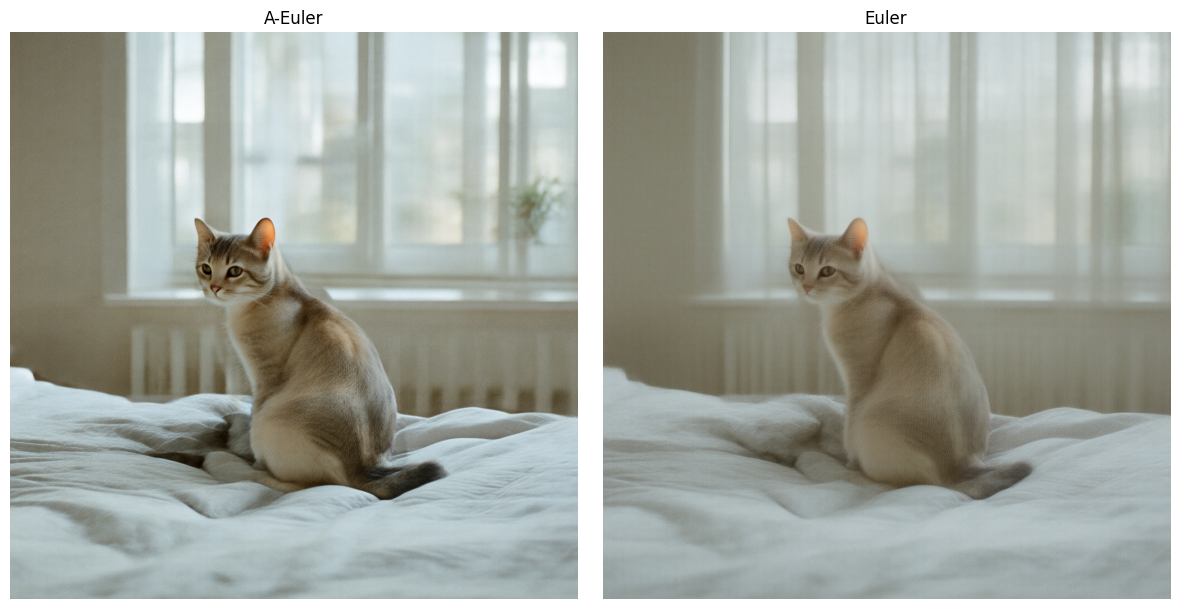

In [5]:
import torch
import matplotlib.pyplot as plt

generator = torch.Generator(device=device).manual_seed(seed)
# 用第一个 scheduler
pipeline.scheduler = scheduler
image1 = pipeline(
    prompt=prompt,
    num_inference_steps=num_inference_steps,
    guidance_scale=2,
    num_images_per_prompt=1,
    output_type='pil',
    generator=generator
).images[0]
image1.save('aEuler.png')
generator = torch.Generator(device=device).manual_seed(seed)
# 用第二个 scheduler
pipeline.scheduler = scheduler_old
image2 = pipeline(
    prompt=prompt,
    num_inference_steps=num_inference_steps,
    guidance_scale=2,
    num_images_per_prompt=1,
    output_type='pil',
    generator=generator
).images[0]
image2.save('Euler.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image1)
axes[0].set_title("A-Euler")
axes[0].axis("off")

axes[1].imshow(image2)
axes[1].set_title("Euler")
axes[1].axis("off")

plt.tight_layout()
plt.show()